# Chapter 6 — Bridge: From Daily Bars to Intraday Data

We've spent five chapters in daily-bar space. This chapter crosses into intraday, because every chapter that follows operates on minute bars. No new statistics — just three things that change going from daily to intraday:

1. **Time has a clock.** Returns are not exchangeable across the session — a 9:32 ET return and a 12:04 ET return come from different distributions.
2. **The bar isn't given to you.** You choose how to slice the data: time, volume, dollar, imbalance.
3. **External events punch through the seasonality.** FOMC at 14:00 ET, CPI at 8:30, NFP at 8:30 — vol explodes on schedule.

The work in this chapter is tooling and intuition: get real intraday data into pandas, see one or two pictures you can't unsee, and learn what bar gaps mean. Math budget is intentionally near-zero.


## §1 — Setup

Load the cached QQQ minute bars from `data/qqq_1min.parquet`. If the cache is missing, see the README for how to regenerate it from Alpaca.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
qqq = pd.read_parquet(DATA / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
print("rows:", f"{len(qqq):,}", " range:", qqq.index.min(), "→", qqq.index.max())
qqq.head()


rows: 101,672  range: 2025-05-08 08:42:00-04:00 → 2026-05-07 16:00:00-04:00


,open,high,low,close,volume,trade_count,vwap
ts_utc,,,,,,,
2025-05-08 08:42:00-04:00,488.47,488.47,488.47,488.47,220.0,3.0,488.470000
2025-05-08 08:44:00-04:00,488.10,488.10,488.10,488.10,100.0,1.0,488.100000
2025-05-08 08:58:00-04:00,488.85,488.85,488.85,488.85,200.0,2.0,488.850000
2025-05-08 09:03:00-04:00,488.79,488.79,488.78,488.78,300.0,4.0,488.785000
2025-05-08 09:30:00-04:00,488.48,488.74,488.17,488.74,4763.0,49.0,488.437834


## §2 — Where the data comes from

These bars came from Alpaca's free-tier IEX feed. The pull script lives in the README; rerun it whenever you want a longer window or a different symbol. From here on we work entirely from the cached parquet — no live API calls in the notebook.

**One thing to internalize about IEX-feed data:** IEX is *one* exchange among many. A "minute bar" from IEX is the OHLCV of trades that printed on IEX during that minute. Minutes when IEX itself had no prints — even if other venues did — produce no bar. We'll see this clearly in §7.

## §3 — Filtering to Regular Trading Hours

Alpaca returns 24-hour bars (pre-market and after-hours included). Most strategies in this curriculum operate Regular Trading Hours only — 9:30 AM to 4:00 PM ET. We filter and add a `minute_of_session` column (0 at the open, 389 at the close).

In [2]:
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN = 9 * 60 + 30
RTH_CLOSE = 16 * 60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
# Zero out the first bar of each session (no overnight return at intraday level)
session_first = rth.groupby("session_date").head(1).index
rth.loc[session_first, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


## §4 — The U-shape

For each minute of the session (0 to 389), compute the mean absolute log return across all sessions. Plot it.

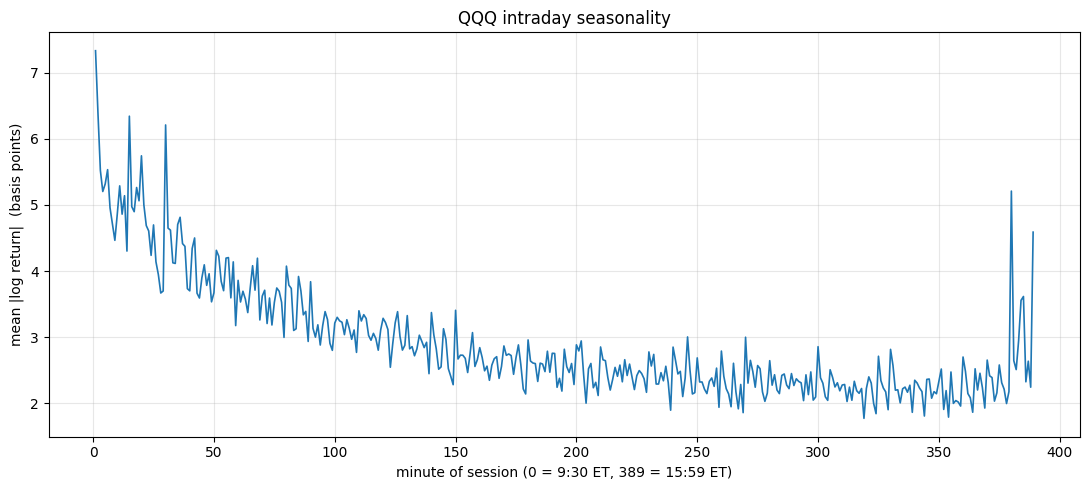

In [3]:
ushape = (
    rth.dropna(subset=["log_ret"])
       .groupby("minute_of_session")["log_ret"]
       .apply(lambda s: s.abs().mean())
)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ushape.index, ushape.values * 1e4, lw=1.2)
ax.set_xlabel("minute of session (0 = 9:30 ET, 389 = 15:59 ET)")
ax.set_ylabel("mean |log return|  (basis points)")
ax.set_title("QQQ intraday seasonality")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The numbers behind the picture:

In [4]:
open5 = ushape.loc[1:5].mean()
mid5  = ushape.loc[180:184].mean()
close5 = ushape.loc[385:389].mean()
print(f"open  5min mean |r|: {open5*1e4:.2f} bp")
print(f"mid   5min mean |r|: {mid5*1e4:.2f} bp")
print(f"close 5min mean |r|: {close5*1e4:.2f} bp")
print(f"open/mid:  {open5/mid5:.2f}×")
print(f"close/mid: {close5/mid5:.2f}×")


open  5min mean |r|: 5.96 bp
mid   5min mean |r|: 2.63 bp
close 5min mean |r|: 3.08 bp
open/mid:  2.27×
close/mid: 1.17×


**What this picture says.** The opening burst is real — the first five minutes after the open run roughly twice as volatile per minute as a midday minute. The classic "U-shape" textbook story (high open, calm midday, high close) is **half-true on QQQ over this window** — the morning peak is sharp, but the closing tail is much milder than folklore suggests. We'll see in §6 that the closing hour is enormously *active* by volume — there's a difference between "vol per return" and "amount of trading." Don't let the textbook picture override what your data says.

**Decision rule unlocked.** Any strategy that doesn't condition on time-of-day implicitly assumes stationarity that is empirically wrong by 2-3× across a session on QQQ. Sizing thresholds, stop losses, signal-significance tests — all need a session-time component or they're mis-calibrated.

## §5 — Event windows preview

The U-shape isn't the whole story. Some sessions have additional structure on top of seasonality. The Federal Open Market Committee (FOMC) announces interest-rate decisions at 14:00 ET on roughly 8 scheduled days per year. Hardcode those dates and overlay.

In [5]:
# FOMC scheduled-meeting dates (announcement at 14:00 ET).
fomc_candidate = [
    "2025-05-07", "2025-06-18", "2025-07-30", "2025-09-17",
    "2025-10-29", "2025-12-10",
    "2026-01-28", "2026-03-18", "2026-04-29",
]
fomc_dates = pd.to_datetime(fomc_candidate).tz_localize("America/New_York")
window_start, window_end = rth.index.min().normalize(), rth.index.max().normalize()
fomc_dates = fomc_dates[(fomc_dates >= window_start) & (fomc_dates <= window_end)]
fomc_set = set(d.normalize() for d in fomc_dates)
rth["is_fomc"] = rth["session_date"].isin(fomc_set)
print(f"FOMC sessions in window: {len(fomc_set)}")


FOMC sessions in window: 8


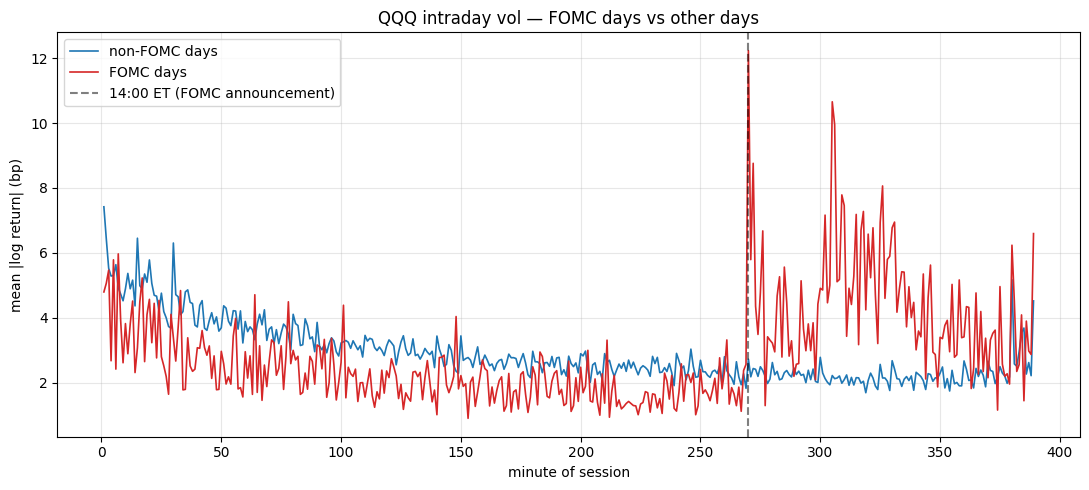

FOMC-day 14:00 |r|: 12.23 bp   non-FOMC: 2.73 bp   ratio: 4.5×


In [6]:
fomc_ushape = (rth[rth["is_fomc"]].dropna(subset=["log_ret"])
               .groupby("minute_of_session")["log_ret"].apply(lambda s: s.abs().mean()))
non_ushape  = (rth[~rth["is_fomc"]].dropna(subset=["log_ret"])
               .groupby("minute_of_session")["log_ret"].apply(lambda s: s.abs().mean()))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(non_ushape.index, non_ushape.values * 1e4, lw=1.2, label="non-FOMC days")
ax.plot(fomc_ushape.index, fomc_ushape.values * 1e4, lw=1.2, label="FOMC days", color="tab:red")
ax.axvline(270, color="black", linestyle="--", alpha=0.5, label="14:00 ET (FOMC announcement)")
ax.set_xlabel("minute of session")
ax.set_ylabel("mean |log return| (bp)")
ax.set_title("QQQ intraday vol — FOMC days vs other days")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

fomc_2pm = rth[(rth["minute_of_session"] == 270) & rth["is_fomc"]]["log_ret"].abs().mean()
non_2pm  = rth[(rth["minute_of_session"] == 270) & ~rth["is_fomc"]]["log_ret"].abs().mean()
print(f"FOMC-day 14:00 |r|: {fomc_2pm*1e4:.2f} bp   non-FOMC: {non_2pm*1e4:.2f} bp   ratio: {fomc_2pm/non_2pm:.1f}×")


**Headline.** At 14:00 ET on FOMC days, the average minute-bar moves ~4.5× more than the same minute on a typical day. The U-shape is no longer the right story — the chart has been re-shaped around the announcement window.

**Forward pointer.** Ch15 (intraday vol & regime detection) builds the toolkit for trading around scheduled events: how to detect that a regime has shifted, how to vol-target through it, when to flat-line. Ch16 (more strategies) builds an event-driven strategy on top of it. Ch6's job is just: see that the spike exists.

## §6 — Bar construction: time vs dollar

The bars we've been working with are **time bars** — every minute, regardless of how much trading happened in it. **Dollar bars** sample every fixed amount of notional traded. On a quiet midday minute they sample less often; on a chaotic opening or closing minute they sample more often. Information content per bar is roughly equalized.

Build dollar bars for one trading day, with a threshold chosen so the day produces ~78 bars (matching what you'd get from 5-minute time bars on a full session).

reference day: 2025-09-18
total dollar volume: $496,002,076
threshold per bar: $6,359,001


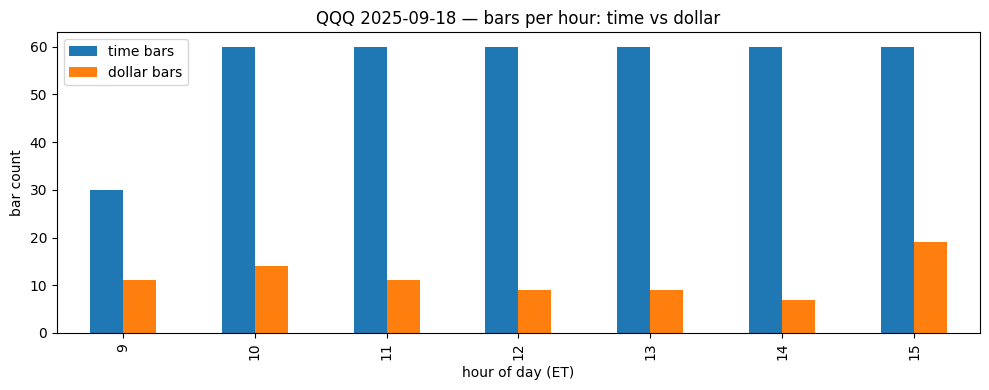

        time bars  dollar bars
ts_utc                        
9              30           11
10             60           14
11             60           11
12             60            9
13             60            9
14             60            7
15             60           19


In [7]:
ref_day = rth[~rth["is_fomc"]]["session_date"].mode().iloc[0]
day = rth[rth["session_date"] == ref_day].copy()
day["dollar"] = day["close"] * day["volume"]
total_dollar = day["dollar"].sum()
n_target = 78
threshold = total_dollar / n_target
print(f"reference day: {ref_day.date()}")
print(f"total dollar volume: ${total_dollar:,.0f}")
print(f"threshold per bar: ${threshold:,.0f}")

day["cum"] = day["dollar"].cumsum()
day["dollar_bar_id"] = (day["cum"] // threshold).astype(int)

per_hour_time = day.groupby(day.index.hour).size()
per_hour_dollar = day.groupby(day.index.hour)["dollar_bar_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
df = pd.DataFrame({"time bars": per_hour_time, "dollar bars": per_hour_dollar})
df.plot(kind="bar", ax=ax)
ax.set_title(f"QQQ {ref_day.date()} — bars per hour: time vs dollar")
ax.set_xlabel("hour of day (ET)")
ax.set_ylabel("bar count")
plt.tight_layout(); plt.show()
print(df)


**Time bars are constant by construction** (60 per hour during RTH). **Dollar bars flex** — far more samples in the closing hour (when activity surges) than in the midday lull.

This connects back to §4. Recall that closing-hour mean |return| was barely elevated (1.17× midday) — yet closing-hour dollar volume produces ~2-3× as many dollar bars as a midday hour. **Vol per return ≠ amount of trading.** Both are intraday phenomena; they don't always move together.

For most of this curriculum we stick with time bars (simpler, regular, what backtest libraries default to). Dollar bars resurface in Ch13 microstructure when slippage modeling needs information-equalized samples. **Imbalance bars** (sampling every fixed amount of signed order-flow imbalance) and **volume bars** (every N shares) are named here and not implemented; see López de Prado, *Advances in Financial Machine Learning* (2018) for the full treatment.

## §7 — Bar gaps and short sessions

Real intraday data has gaps. Some are legitimate (no trades on IEX in that minute); some are vendor-side issues; some are short trading sessions (early closes around holidays). Audit the data before trusting it.

In [8]:
zero_vol = (rth["volume"] == 0).sum()
print(f"RTH bars present with volume == 0: {zero_vol} ({100*zero_vol/len(rth):.4f}%)")

sess_counts = rth.groupby("session_date").size()
expected = 390
short_sessions = sess_counts[sess_counts < expected]
print(f"\nsessions with < {expected} bars: {len(short_sessions)} of {len(sess_counts)}")
print(f"average bars per session: {sess_counts.mean():.1f}")
print(f"median bars per session: {sess_counts.median():.0f}")


RTH bars present with volume == 0: 0 (0.0000%)

sessions with < 390 bars: 172 of 251
average bars per session: 379.8
median bars per session: 387


**The honest finding on this data.** Of the bars *present* in the parquet, none have zero volume — every minute we have, traded. But the *vast majority of sessions are missing some bars*. Average ~380 of 390 expected. This is what an IEX-only feed looks like: minutes when no trade printed *on IEX* (even if other venues had trades) produce no bar at all.

**Practical implication.** When you join intraday bars to a session-time index, you'll get NaNs scattered through the data. You have two reasonable choices: (a) reindex to the full minute grid and forward-fill price (treating gaps as "no change"), or (b) leave the gaps and aggregate over only the bars you have. Either is defensible — what's *not* defensible is silently treating the gappy data as if every session has 390 bars. We'll lean on the second approach throughout this curriculum (groupby preserves NaNs), but flag where it matters.

Below: actual short sessions in the data, sorted by how short. Most are within 10-30 bars of the full 390 — IEX gaps. The genuinely-short ones (< 300 bars) are likely real holiday early-closes (1:00 PM ET close).

In [9]:
short_sessions.sort_values().head(15)


session_date
2025-07-03 00:00:00-04:00    213
2025-12-24 00:00:00-05:00    218
2025-11-28 00:00:00-05:00    224
2025-06-27 00:00:00-04:00    332
2025-07-16 00:00:00-04:00    339
2025-06-04 00:00:00-04:00    342
2025-05-09 00:00:00-04:00    344
2025-07-22 00:00:00-04:00    345
2025-08-26 00:00:00-04:00    346
2025-06-12 00:00:00-04:00    346
2025-06-20 00:00:00-04:00    349
2025-06-09 00:00:00-04:00    354
2025-07-30 00:00:00-04:00    354
2025-07-18 00:00:00-04:00    354
2025-06-16 00:00:00-04:00    356
dtype: int64

## §8 — Exercises

See the README for full prompts. Briefly:

1. **SPY vs QQQ U-shape comparison.** Repeat §4 on SPY (`data/spy_1min.parquet`) and overlay both curves. Same shape? Same magnitude? Where do they diverge?
2. **Dollar bars on an FOMC day.** Repeat §6 on one of the FOMC dates from §5. How does bars-per-hour differ from a quiet day?
3. **CPI release seasonality.** CPI prints monthly at 8:30 AM ET (pre-market). Add CPI dates, re-filter to include pre-market (8:30 onwards), and check whether the spike lands at 8:30 in pre-market or rolls into the 9:30 open.
4. **Bar-gap audit on a problem session.** Find one of the *very* short sessions from §7 — cross-reference to the NYSE calendar — early close, or vendor outage?
